In [1]:
%load_ext pycograd

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pycograd as pg

rng = np.random.default_rng(42)

m = 40
centers = np.array([[2.0, 2.0], [-2.0, 2.0], [0.0, -2.5]])
X = np.vstack([rng.normal(c, 0.5, (m, 2)) for c in centers])
labels = np.repeat(np.arange(3), m)
Y = np.eye(3)[labels]   # one-hot, 3 classes

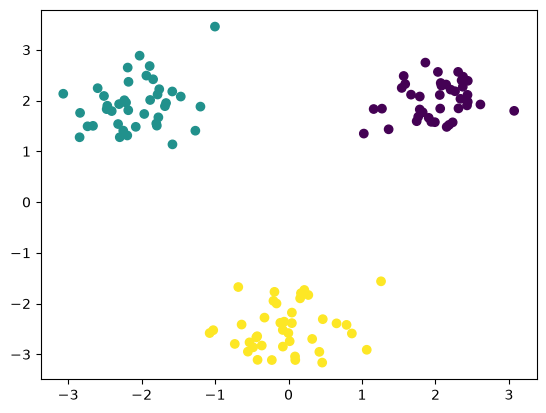

In [12]:
plt.scatter(X[:,0], X[:,1], c=labels)

In [37]:
with params{
    w1 = 0.3 * rng.standard_normal((2, 16))
    b1 = np.zeros(16)
    w2 = 0.3 * rng.standard_normal((16, 3))
    b2 = np.zeros(3)
} as weights:
    logits = $ |> $ @ w1 + b1 |> pg.relu |> $ @ w2 + b2
    forward = pg.capture($ |> logits |> pg.softmax, X) |>> fwd_raw |> pg.optimize
    loss = lambda x, y: x |> logits |> pg.cross_entropy($, y)
    optimized = pg.value_and_grad(pg.capture(loss, X, Y)) |>> vg_raw |> pg.optimize
    obj = |> X |> logits |> cross_entropy($, Y)
    for _i in range(10):
        _values, grads = optimized(X, Y)
        weights.step(grads, 0.5)

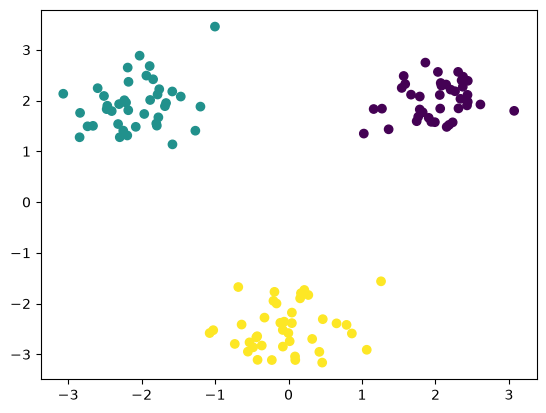

In [38]:
plt.scatter(X[:,0], X[:,1], c=np.argmax(forward(X), axis=1))

In [45]:
vg_raw

graph(%0:f64[120,2], %1:f64[120,3]) {
  %2 = weight 'w1' -> f64[2,16]
  %3 = matmul %0 %2 -> f64[120,16]
  %4 = weight 'b1' -> f64[16]
  %5 = add %3 %4 -> f64[120,16]
  %6 = maximum %5 0.0 -> f64[120,16]
  %7 = weight 'w2' -> f64[16,3]
  %8 = matmul %6 %7 -> f64[120,3]
  %9 = weight 'b2' -> f64[3]
  %10 = add %8 %9 -> f64[120,3]
  %11 = logsumexp %10 {axis=-1, keepdims=True} -> f64[120,1]
  %12 = sub %10 %11 -> f64[120,3]
  %13 = mul %1 %12 -> f64[120,3]
  %14 = sum %13 {axis=-1} -> f64[120]
  %15 = mean %14 -> f64[]
  %16 = neg %15 -> f64[]
  %17 = const 1.0 -> f64[]
  %18 = neg %17 -> f64[]
  %19 = broadcast_to %18 i64[1] -> f64[120]
  %20 = div %19 120.0 -> f64[120]
  %21 = expand_dims %20 -1 -> f64[120,1]
  %22 = broadcast_to %21 i64[2] -> f64[120,3]
  %23 = mul %22 %12 -> f64[120,3]
  %24 = mul %22 %1 -> f64[120,3]
  %25 = neg %24 -> f64[120,3]
  %26 = sum %25 {axis=(1,), keepdims=True} -> f64[120,1]
  %27 = softmax %10 {axis=-1} -> f64[120,3]
  %28 = mul %27 %26 -> f64[120,3]
  %

In [5]:
# Eager alternative to the compiled `value_and_grad(capture(...))` step above:
# `weights.grad(obj)` differentiates an ambient `|>` objective directly and hands back a
# ParamDict -- the very thing `weights.step` consumes, no capture/optimize needed. Run it
# inside `with weights:` so the w1/b1/... proxies are live.
with weights:
    obj = |> X |> logits |> cross_entropy($, Y)
    value, grads = weights.grad(obj)

float(value), {name: g.shape for name, g in grads.items()}

(0.03296407279607119, {'w1': (2, 16), 'b1': (16,), 'w2': (16, 3), 'b2': (3,)})

In [6]:
# `jit=True` compiles the gradient into pycograd's own optimized forward+backward graph
# (capture -> grad_graph -> optimize) the first time, caches it on `weights`, and replays it
# each call -- the manual `optimize(value_and_grad(capture(...)))` pattern from the training
# cell, now behind a flag. On the numpy backend the objective takes its data positionally
# (so the trace flows through the weights); the result matches the eager path.
with weights:
    loss = lambda x, y: x |> logits |> cross_entropy($, y)
    v_eager, g_eager = weights.grad(loss, X, Y)            # eager numpy tape
    v_jit, g_jit = weights.grad(loss, X, Y, jit=True)      # compiled once, cached on `weights`
    _ = weights.grad(loss, X, Y, jit=True)                 # reuses the cached graph

# same value and same per-weight gradients as the eager path:
bool(np.isclose(v_eager, v_jit)), {k: bool(np.allclose(g_eager[k], g_jit[k])) for k in weights}

(True, {'w1': True, 'b1': True, 'w2': True, 'b2': True})